In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
import seaborn as sns

In [3]:
def downsample(input_data_df, original_sampling_rate_hz, target_sampling_rate_hz):
    """Downsample the data in the input_data_df from the original sampling rate to a given target sampling rate."""
    data_array = input_data_df.values
    len_data = data_array.shape[0]
    current_x = np.linspace(0, len_data, len_data)
    data_array_downsampled = interp1d(current_x, data_array, axis=0)(
        np.linspace(0, len_data, int(len_data * target_sampling_rate_hz / original_sampling_rate_hz))
    )

    output_data_df = pd.DataFrame(data_array_downsampled, columns=input_data_df.columns)

    return output_data_df

In [4]:
# low_pass_filter_Data
def low_pass_filter(sig, fs, f_cut, order):
    """
    applies zero-lag butterworth filter to a signal
    :param sig: signal to be filtered - np.array
    :param fs: sampling frequency of sig - integer
    :param f_cut: cut-off frequency (low-pass) - integer
    :param order: order of filter - integer
    :return sig_filt: filtered signal - np array
    """
    # design filter
    nf = f_cut/(fs/2)
    b, a = butter(order, nf, btype='low')

    # apply filter
    sig_filt = filtfilt(b, a, sig.values, axis=0, padtype='odd', padlen=3*(max(len(b), len(a))-1))
    return sig_filt

In [5]:
def segment_steps(force_df, fs):
    f_vert = pd.DataFrame(-force_df["Fz"])
     # get highly smoothed signal for peak detection
    highly_smoothed_sig = low_pass_filter(f_vert, fs, 5, 4)

    # grab all smooth peaks above 500 Newtons
    peaks, _ = find_peaks(highly_smoothed_sig.squeeze(), height=500)
    # remove first and last peaks to avoid partial GRFs
    # peaks = np.delete(peaks, [0, -1])

    # squeeze to np array for further processing
    slightly_smoothed_sig = f_vert.values.squeeze()

    # extract HS (search from peak to the left while GRF > 20)
    HS_list = []
    # extract TO (search from peak to the right while GRF > 20)
    TO_list = []

    for peak in peaks:
        peak_hs_copy = peak
        while (peak_hs_copy > 0) & (slightly_smoothed_sig[peak_hs_copy] > 20):
            peak_hs_copy = peak_hs_copy - 1
        HS_list.append(peak_hs_copy + 1)  # go one back

        peak_to_copy = peak
        while (peak_to_copy < len(slightly_smoothed_sig)) & (slightly_smoothed_sig[peak_to_copy] > 20):
            peak_to_copy = peak_to_copy + 1
        TO_list.append(peak_to_copy - 1)  # go on back

    HS_list = list(set(HS_list))  # removes possible duplicates
    HS_list.sort()

    TO_list = list(set(TO_list))  # removes possible duplicates
    TO_list.sort()

    # make sure to start with HS and end with TO
    if HS_list[0] > TO_list[0]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    elif HS_list[-1] > TO_list[-1]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    try:
        len(TO_list) == len(HS_list)
    except:
        print("different number of HS and TO detected, something is wrong here..")
    
    IC = np.array(HS_list)
    TO = np.array(TO_list)
    return IC, TO

In [9]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample

def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """

    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    IC_side = [rfd_1500[0]]

    # next IC of the same side has to be at least 250 ms away (fs/4)
    for i in range(1, len(rfd_1500)):
        if rfd_1500[i] - rfd_1500[i - 1] > sampling_rate / 4:
            IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side


def pi_separate_steps(pi_left, pi_right, pi_events):
    """
    separates the Stance phases for each step and save in dict
    :param pi_left: pressure data left foot 3d array shape [31 x 11 x frames]
    :param pi_right: pressure data right foot 3d array shape [31 x 11 x frames]
    :param pi_events: dict with IC and TO indices for each side
    :return pi_steps: dict with data for each step (stance phase) - values 3d array[31 x 11 x [IC:TO]]
    """
    # init dict
    pi_steps = {}

    # left side
    for i in range(len(pi_events['IC_left'])):
        pi_steps['left_'+str(i)]=pi_left[:,:,pi_events['IC_left'][i]:pi_events['TO_left'][i]]
    # right side
    for i in range(len(pi_events['IC_right'])):
        pi_steps['right_'+str(i)]=pi_right[:,:,pi_events['IC_right'][i]:pi_events['TO_right'][i]]

    return pi_steps


In [10]:
# load
pi_data = pd.read_csv('df.csv', index_col=0)
pi_data.set_index(np.linspace(0, len(pi_data)-1, len(pi_data),dtype=int))

,0,1,2,3,4,5,6,7,8,9,10,foot,frame,row_count
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,left,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,left,1,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,left,1,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,left,1,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,left,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372057,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,right,6001,27
372058,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,right,6001,28
372059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,right,6001,29
372060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,right,6001,30


In [11]:
    pi_left, pi_right = separate_sides(pi_data)

#   - (Filter)

#   - reshape (by frames)
#   - calculate force [N]
    force_left = pi_force(pi_left)[1:]
    force_right = pi_force(pi_right)[1:]

#   - (calculate rate of force development)
#   - step segmentation
    sampling_rate_pi = 100
    pi_events = pi_step_segmentation(force_left, force_right, sampling_rate_pi)

In [13]:
ic_pi=np.hstack([pi_events['IC_left'], pi_events['IC_right']])
ic_pi.sort()
to_pi=np.hstack([pi_events['TO_left'], pi_events['TO_right']])
to_pi.sort()

In [12]:
# import force data
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\PI_FP_IMU\\RUN_03.csv', sep = ',', header = [3], low_memory = False)
ff = df.iloc[df[df['Frame']=='Frame'].index[0]+2:, :]
ff.columns = df.iloc[df[df['Frame']=='Frame'].index[0],:].values.tolist()
force_df = ff[['Frame', 'Sub Frame', 'Fx','Fy','Fz','Mx','My','Mz','Cx','Cy','Cz']].astype('float')
force_df=downsample(force_df, 1000,100)

In [14]:
# find true peaks force plate
ic_true, to_true = segment_steps(force_df, 100)
print('number of steps :', len(ic_true))

number of steps : 156


## some trouble detecting the first steps

In [15]:
o=0

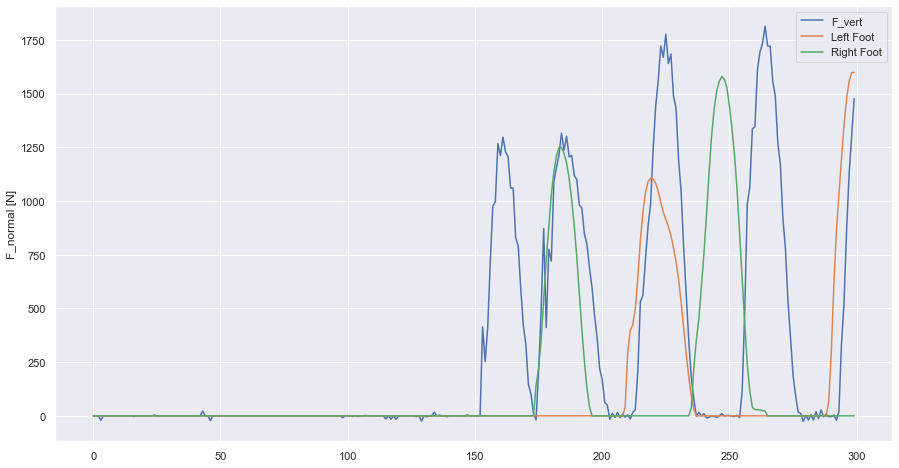

In [18]:
# example data
o+=250
o=0
sns.set_theme()
fig = plt.figure(figsize=[15,8])
plt.plot(-force_df['Fz'].values[o:o+300], label = 'F_vert')
plt.plot(force_left[o:o+300], label='Left Foot')
plt.plot(force_right[o:o+300], label='Right Foot')
plt.ylabel('F_normal [N]')
plt.legend()

## constant delay of right PI Sensor

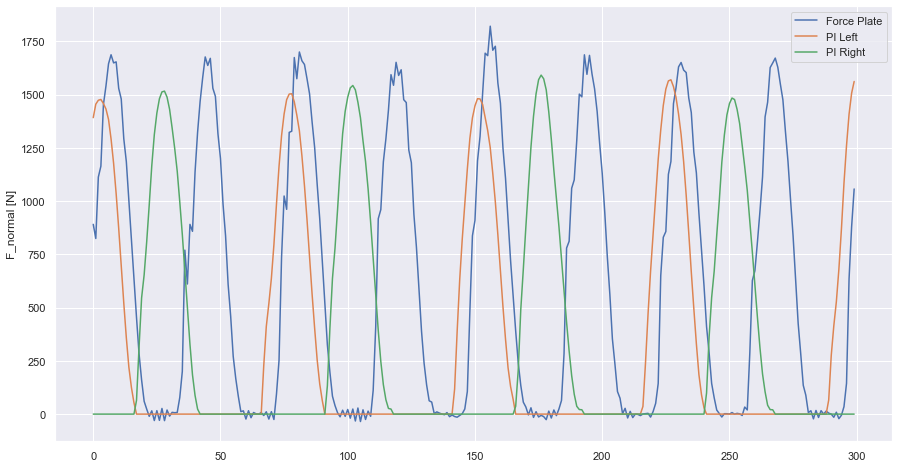

In [154]:
# example data
o+=600
o=5700
sns.set_theme()
fig = plt.figure(figsize=[15,8])
plt.plot(-force_df['Fz'].values[o:o+600], label='Force Plate')
plt.plot(force_left[o:o+600], label='PI Left')
plt.plot(force_right[o:o+600], label='PI Right')
plt.ylabel('F_normal [N]')
plt.legend()

In [31]:
print('true steps:', len(ic_true))

true steps: 156


In [29]:
print('PI left steps:', len(pi_events['IC_left']))
print('PI right steps:', len(pi_events['IC_right']))
print('PI total:', len(pi_events['IC_left'])+len(pi_events['IC_right']))

PI left steps: 77
PI right steps: 77
PI total: 154


In [39]:
print('first 3 true IC:', ic_true[:3])
print('first 3 Pi-left IC:', pi_events['IC_left'][:3])
print('first 3 Pi-right IC:', pi_events['IC_right'][:3])
print('--> drop first 2 true IC,\n--> then start with left')

first 3 true IC: [153 175 213]
first 3 Pi-left IC: [208 288 365]
first 3 Pi-right IC: [173 234 314]
--> drop first 2 true IC,
--> then start with left


In [40]:
ic_true=ic_true[2:]

In [45]:
pi_left = pi_events['IC_left']
true_left = ic_true[::2]

In [46]:
pi_right = pi_events['IC_right'][1:]
true_right = ic_true[1::2][:-1]

[5 6 5 4 4 6 5 5 5 6 4 5 5 5 3 5 5 4 5 5 6 5 5 5 6 4 5 5 4 6 6 4 5 6 5 4 5
 5 6 6 6 4 5 5 5 5 6 6 6 5 5 6 6 6 5 6 5 6 6 7 5 6 6 5 6 6 5 6 5 6 6 6 6 6
 6 5 6]
Offset Left =  5


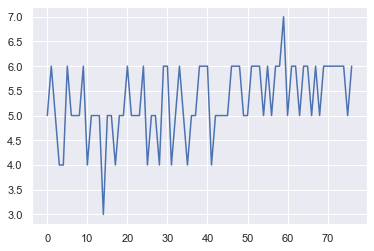

In [52]:
# offset left
print(true_left-pi_left)
plt.plot(true_left-pi_left)
print('Offset Left = ', int(np.median(true_left-pi_left)))

[21 17 15 16 17 17 16 18 18 17 18 17 16 17 18 17 17 18 18 17 18 17 18 16
 16 18 18 17 17 18 18 17 18 18 19 18 18 17 17 16 19 18 16 17 18 18 17 17
 19 18 17 19 17 17 17 17 18 17 19 17 18 18 18 18 18 19 20 17 21 17 20 20
 19 18 19 18]
Offset Right =  18


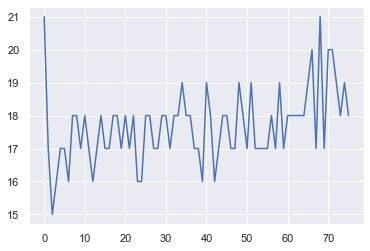

In [53]:
# offset right
print(true_right-pi_right)
plt.plot(true_right-pi_right)
print('Offset Right = ', int(np.median(true_right-pi_right)))

In [54]:
fr = pd.Series(force_right, index=range(17,6017), name='PI_right')
fl = pd.Series(force_left, index=range(4,6004), name='PI_left')
ft = -force_df['Fz']

In [55]:
df = pd.concat([ft, fl, fr], axis =1).dropna()
df

,Fz,PI_left,PI_right
17,-0.000000,0.00,0.0
18,-0.000000,0.00,0.0
19,-0.000000,0.00,0.0
20,-0.000000,0.00,0.0
21,-0.000000,0.00,0.0
...,...,...,...
5995,34.848502,414.02,0.0
5996,144.474782,527.23,0.0
5997,635.785304,680.38,0.0
5998,879.181625,869.13,0.0


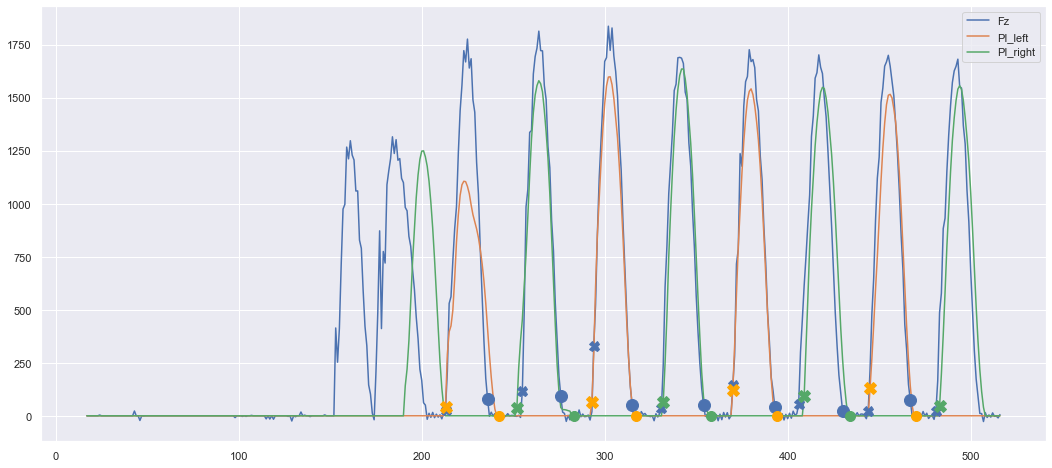

In [58]:
w1 =0
w2 = w1+500
df[w1:w2].plot(figsize=[18,8])
plt.plot(ft[ic_true].loc[w1:w2], 'bX', markersize=10)
plt.plot(ft[to_true[2:]].loc[w1:w2], 'bo', markersize=12)
plt.plot(fr[pi_right+18].loc[w1:w2], 'gX', markersize=12)
plt.plot(fr[pi_events['TO_right'][1:]+18].loc[w1:w2], 'go', markersize=10)
plt.plot(fl[pi_left+5].loc[w1:w2], 'X', color='orange', markersize=12)
plt.plot(fl[pi_events['TO_left']+5].loc[w1:w2], 'o', color='orange', markersize=10)

In [57]:
ft[ic_true].loc[600:1200]

634     144.235979
672      72.465599
709      61.304678
747      46.662130
786     231.396528
824     180.339040
862      95.805903
901     164.187319
938      21.196734
976      35.564847
1015     64.417578
1053    217.469087
1090     58.354776
1128    182.298647
1164     21.978982
Name: Fz, dtype: float64